# Wine Quality Prediction (WineQT.csv) — CRISP-DM Notebook

This notebook reproduces the end-to-end pipeline used in the project:
- **Data Understanding (EDA)** with plots
- **Data Preparation** (drop `Id`, train/test split, scaling)
- **Modeling** (Linear Regression vs Random Forest)
- **Evaluation** (RMSE, R², Actual vs Predicted)
- **Interpretability** (Random Forest feature importances)
- **Deployment step** (save best model as `.joblib`)

> Put `WineQT.csv` in the same folder as this notebook before running.


In [26]:
# Imports
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import joblib

from IPython.display import display

plt.rcParams["figure.dpi"] = 120
sns.set_context("notebook")


## 1) Business Understanding

**Goal:** Predict the wine **quality score** using physicochemical measurements to support fast quality screening.


## 2) Data Understanding (EDA)

In [27]:
# Load data
DATA_PATH = "WineQT.csv"
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Cannot find '{DATA_PATH}'. Put WineQT.csv next to this notebook or adjust DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Column names:", df.columns.tolist())
display(df.head())

print("\nBasic statistics:")
display(df.describe().T)


Dataset shape: (1143, 13)
Column names: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4



Basic statistics:


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


,quality,count
0,3,6
1,4,33
2,5,483
3,6,462
4,7,143
5,8,16


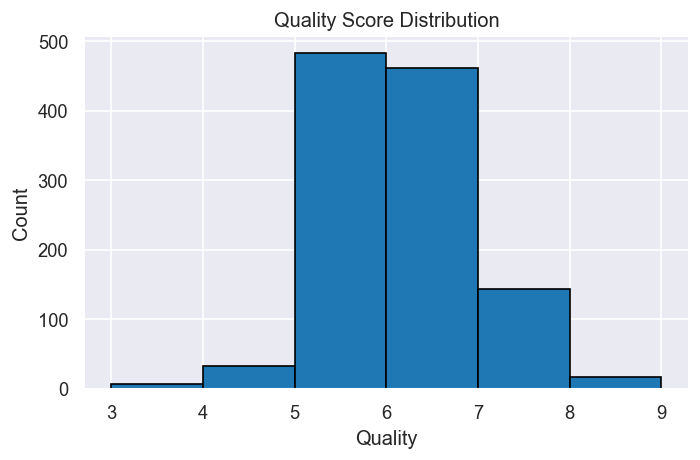

Saved plot: quality_distribution.png


In [28]:
# Quality distribution (counts + histogram)
quality_counts = df["quality"].value_counts().sort_index()
display(pd.DataFrame({"quality": quality_counts.index, "count": quality_counts.values}))

plt.figure(figsize=(6,4))
plt.hist(df["quality"], bins=range(df["quality"].min(), df["quality"].max()+2), edgecolor="black")
plt.title("Quality Score Distribution")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("quality_distribution.png", bbox_inches="tight")
plt.show()

print("Saved plot: quality_distribution.png")


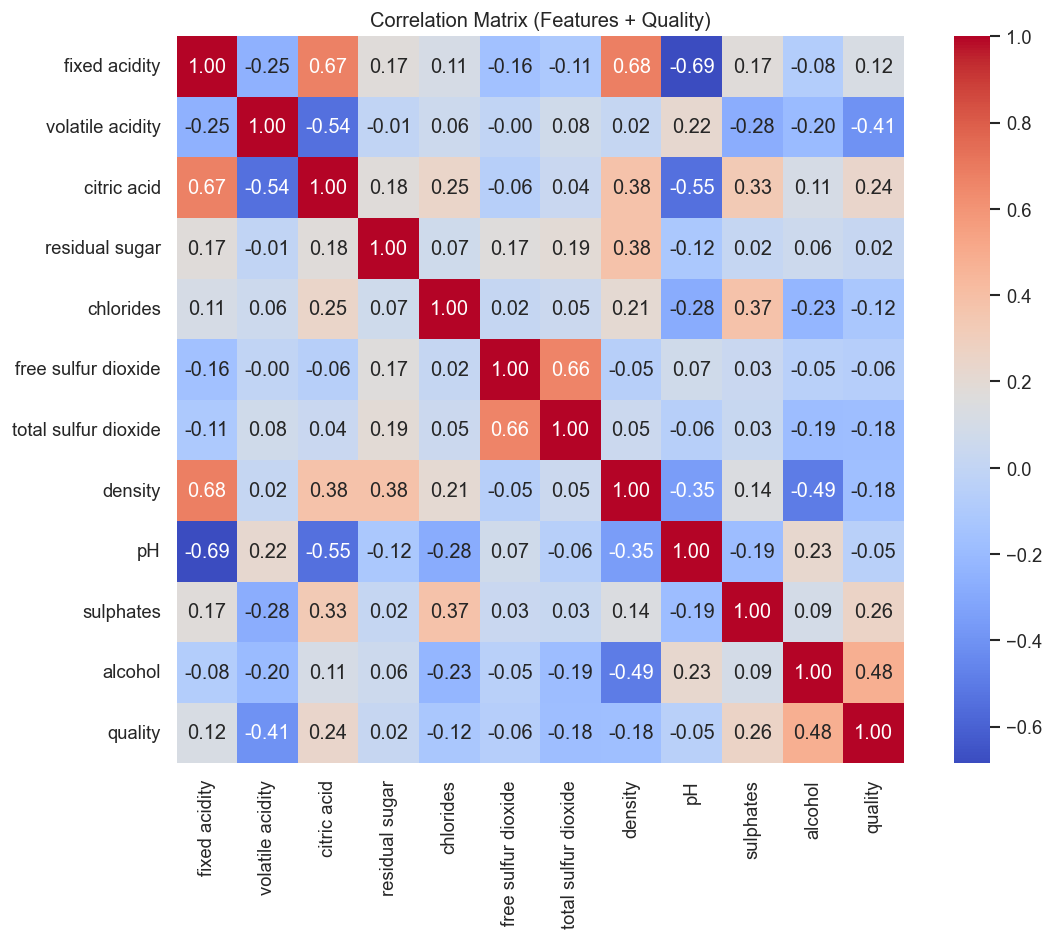

Saved plot: correlation_matrix.png


In [29]:
# Correlation heatmap (excluding Id if present)
df_corr = df.drop(columns=["Id"], errors="ignore")
corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar=True)
plt.title("Correlation Matrix (Features + Quality)")
plt.tight_layout()
plt.savefig("correlation_matrix.png", bbox_inches="tight")
plt.show()

print("Saved plot: correlation_matrix.png")


## 3) Data Preparation

In [30]:
from IPython.display import display

# Drop Id (identifier)
df_clean = df.drop(columns=["Id"], errors="ignore").copy()
print("Dropped 'Id' column (if present). Current columns:", df_clean.columns.tolist())

# Missing values check
missing = df_clean.isnull().sum()
display(pd.DataFrame({"missing": missing}))

if missing.sum() == 0:
    print("No missing values found.")
else:
    print("WARNING: Missing values detected. Consider imputation or removal.")


Dropped 'Id' column (if present). Current columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


,missing
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


No missing values found.


In [31]:
# Features / target split
X = df_clean.drop(columns=["quality"])
y = df_clean["quality"]

# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

train_dist = y_train.value_counts(normalize=True).sort_index()
test_dist  = y_test.value_counts(normalize=True).sort_index()

display(pd.DataFrame({"quality": train_dist.index, "train_proportion": train_dist.values}))
display(pd.DataFrame({"quality": test_dist.index, "test_proportion": test_dist.values}))

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nBefore scaling (first training sample):", np.round(X_train.iloc[0].values, 2))
print("After  scaling (first training sample):", np.round(X_train_scaled[0], 2))


Training set size: 914 samples
Test set size: 229 samples


,quality,train_proportion
0,3,0.005470
1,4,0.028446
2,5,0.422319
3,6,0.404814
4,7,0.124726
5,8,0.014223


,quality,test_proportion
0,3,0.004367
1,4,0.030568
2,5,0.423581
3,6,0.401747
4,7,0.126638
5,8,0.013100



Before scaling (first training sample): [ 8.3   0.6   0.25  2.2   0.12  9.   38.    1.    3.15  0.53  9.8 ]
After  scaling (first training sample): [-0.01  0.39 -0.11 -0.26  0.61 -0.64 -0.24 -0.3  -1.04 -0.73 -0.61]


## 4) Modeling

In [32]:
# Define models
lin_reg = LinearRegression()
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)

# 5-fold cross-validation (R²)
cv_lin = cross_val_score(lin_reg, X_train_scaled, y_train, cv=5, scoring="r2")
cv_rf  = cross_val_score(rf_reg,  X_train_scaled, y_train, cv=5, scoring="r2")

print("Model: Linear Regression")
print("  5-fold CV R^2 scores:", np.round(cv_lin, 3))
print(f"  CV Mean R^2 = {cv_lin.mean():.3f} (std = {cv_lin.std():.3f})")

print("\nModel: Random Forest")
print("  5-fold CV R^2 scores:", np.round(cv_rf, 3))
print(f"  CV Mean R^2 = {cv_rf.mean():.3f} (std = {cv_rf.std():.3f})")

# Fit on full training data
lin_reg.fit(X_train_scaled, y_train)
rf_reg.fit(X_train_scaled, y_train)


Model: Linear Regression
  5-fold CV R^2 scores: [0.378 0.296 0.26  0.389 0.386]
  CV Mean R^2 = 0.342 (std = 0.054)

Model: Random Forest
  5-fold CV R^2 scores: [0.508 0.358 0.368 0.38  0.442]
  CV Mean R^2 = 0.411 (std = 0.057)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 5) Evaluation

In [33]:
# Predictions + Metrics
y_pred_lin = lin_reg.predict(X_test_scaled)
y_pred_rf  = rf_reg.predict(X_test_scaled)

lin_mse  = mean_squared_error(y_test, y_pred_lin)
lin_rmse = np.sqrt(lin_mse)
lin_r2   = r2_score(y_test, y_pred_lin)

rf_mse  = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2   = r2_score(y_test, y_pred_rf)

print("Test Metrics")
print(f"Linear Regression -> RMSE: {lin_rmse:.3f},  R^2: {lin_r2:.3f}")
print(f"Random Forest    -> RMSE: {rf_rmse:.3f},  R^2: {rf_r2:.3f}")

best_name = "Random Forest" if rf_r2 >= lin_r2 else "Linear Regression"
print(f"\nBest model by R^2: {best_name}")


Test Metrics
Linear Regression -> RMSE: 0.628,  R^2: 0.388
Random Forest    -> RMSE: 0.596,  R^2: 0.449

Best model by R^2: Random Forest


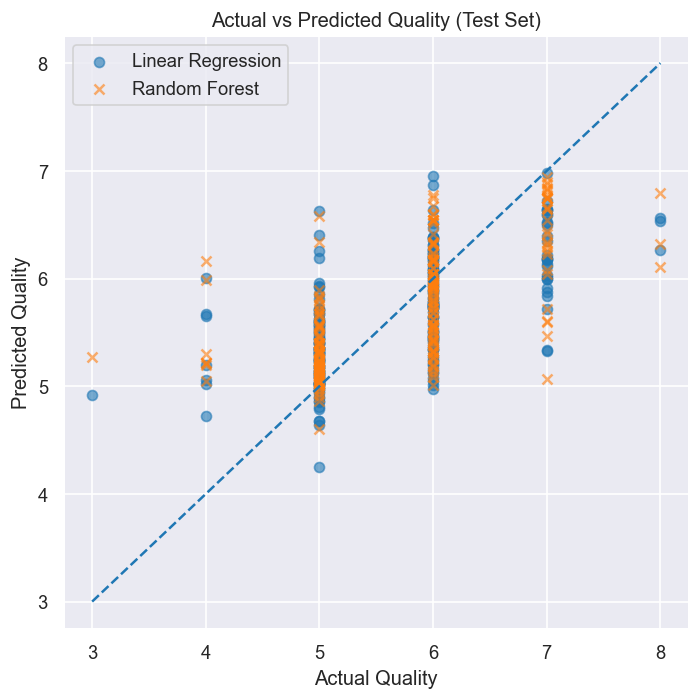

Saved plot: actual_vs_predicted.png


In [34]:
# Visualization: Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lin, alpha=0.6, label="Linear Regression", marker="o")
plt.scatter(y_test, y_pred_rf,  alpha=0.6, label="Random Forest", marker="x")

min_q, max_q = y_test.min(), y_test.max()
plt.plot([min_q, max_q], [min_q, max_q], linestyle="--")

plt.title("Actual vs Predicted Quality (Test Set)")
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.legend()
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", bbox_inches="tight")
plt.show()

print("Saved plot: actual_vs_predicted.png")


## 6) Interpretation: Feature Importances (Random Forest)

,importance
alcohol,0.283612
sulphates,0.138444
volatile acidity,0.126262
total sulfur dioxide,0.072082
pH,0.063260
fixed acidity,0.058337
chlorides,0.057546
citric acid,0.056960
density,0.053683
residual sugar,0.046423


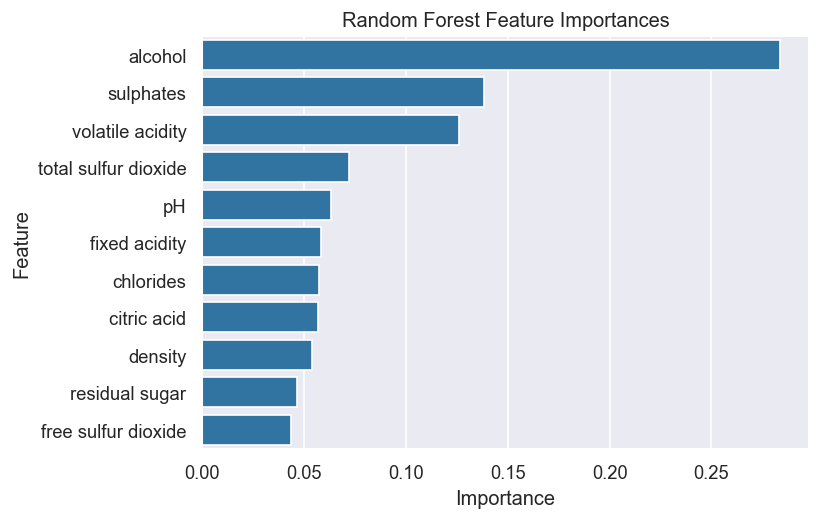

Saved plot: feature_importances.png


In [35]:
# Feature importances
importances = pd.Series(rf_reg.feature_importances_, index=X.columns).sort_values(ascending=False)
display(importances.to_frame("importance"))

plt.figure(figsize=(7,4.5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("feature_importances.png", bbox_inches="tight")
plt.show()

print("Saved plot: feature_importances.png")


## 7) Deployment Step: Save Best Model

In [36]:
# Save best model (by test R²)
if rf_r2 >= lin_r2:
    model_name = "random_forest_wine_quality_model.joblib"
    joblib.dump(rf_reg, model_name)
else:
    model_name = "linear_regression_wine_quality_model.joblib"
    joblib.dump(lin_reg, model_name)

print(f"Saved model: {model_name}")


Saved model: random_forest_wine_quality_model.joblib


## Summary
- Dataset shows strong concentration around quality 5–6 (imbalance).
- Random Forest typically outperforms Linear Regression on this dataset.
- Alcohol is the strongest predictor, followed by sulphates and volatile acidity.
